### KNN Classification - Student Dropout & Academic Success

Dataset: Predict Students Dropout and Academic Success

Source: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

Size: 4,424 students | 36 features | 3 target classes (Dropout, Enrolled, Graduate)

Features include: Demographics, application details, 1st & 2nd semester academic performance, socioeconomic indicators (GDP, unemployment, inflation)


In [29]:
# Imports

!pip install ucimlrepo imbalanced-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.feature_selection import VarianceThreshold

# Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)

from imblearn.over_sampling import SMOTE
import pkg_resources

packages = [
    "numpy", "pandas", "scikit-learn", "matplotlib",
    "seaborn", "imbalanced-learn", "ucimlrepo"
]

for p in packages:
    try:
        print(f"{p}: {pkg_resources.get_distribution(p).version}")
    except:
        print(f"{p}: not installed")

numpy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
imbalanced-learn: 0.14.1
ucimlrepo: 0.0.7


Shape: (4424, 36)  |  Missing values: 0
Data types: {dtype('int64'): np.int64(29), dtype('float64'): np.int64(7)}

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794


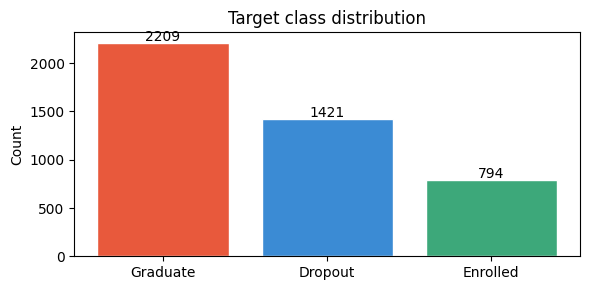

In [15]:
dataset = fetch_ucirepo(id=697) # Dataset
X, y = dataset.data.features, dataset.data.targets

print(f'Shape: {X.shape}  |  Missing values: {X.isnull().sum().sum()}')
print(f'Data types: {dict(X.dtypes.value_counts())}')
print('\nTarget distribution:')
print(y['Target'].value_counts().to_string())

# Class distribution chart
counts = y['Target'].value_counts()
plt.figure(figsize=(6, 3))
bars = plt.bar(counts.index, counts.values, color=['#E8593C','#3B8BD4','#3DA87A'], edgecolor='white')
for b in bars: plt.text(b.get_x()+b.get_width()/2, b.get_height()+20, str(int(b.get_height())), ha='center', fontsize=10)
plt.title('Target class distribution')
plt.ylabel('Count')
plt.tight_layout(); plt.show()


In [16]:
# 1. Impute
imputer = SimpleImputer(strategy='mean')
X_imp = imputer.fit_transform(X)

# 2. Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y['Target'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# 3. Feature selection
sel = VarianceThreshold(threshold=0.01)
X_sel = sel.fit_transform(X_imp)
print(f'Features: {X_imp.shape[1]} -> {X_sel.shape[1]} ({X_imp.shape[1]-X_sel.shape[1]} low-variance removed)')

# 4. Scale
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_sel)

# 5. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y_enc, test_size=0.20, random_state=42, stratify=y_enc)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print('Train distribution:', dict(zip(le.classes_, np.bincount(y_train))))
print('Test  distribution:', dict(zip(le.classes_, np.bincount(y_test))))

Label mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Features: 36 -> 36 (0 low-variance removed)
Train: 3539 | Test: 885
Train distribution: {'Dropout': np.int64(1137), 'Enrolled': np.int64(635), 'Graduate': np.int64(1767)}
Test  distribution: {'Dropout': np.int64(284), 'Enrolled': np.int64(159), 'Graduate': np.int64(442)}


Best K: 17  (CV accuracy: 0.7152)


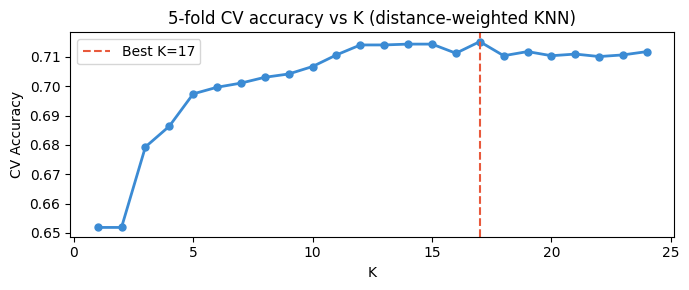

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_range = range(1, 25)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean', n_jobs=-1)
    score = cross_val_score(knn, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    cv_scores.append(score)

best_k = list(k_range)[np.argmax(cv_scores)]
print(f'Best K: {best_k}  (CV accuracy: {max(cv_scores):.4f})')

plt.figure(figsize=(7, 3))
plt.plot(k_range, cv_scores, marker='o', markersize=5, color='#3B8BD4', linewidth=2)
plt.axvline(best_k, linestyle='--', color='#E8593C', linewidth=1.5, label=f'Best K={best_k}')
plt.title('5-fold CV accuracy vs K (distance-weighted KNN)')
plt.xlabel('K'); plt.ylabel('CV Accuracy'); plt.legend(); plt.tight_layout(); plt.show()

In [18]:
knn = KNeighborsClassifier(
    n_neighbors=best_k,       # tuned via 5-fold CV
    weights='distance',       # inverse-distance weighting
    metric='euclidean',       # standard L2 distance
    algorithm='auto',         # sklearn auto-selects kd_tree/ball_tree/brute
    n_jobs=-1                 # parallelise across CPU cores
)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(f'Model trained. Predicting on {X_test.shape[0]} test samples.')

Model trained. Predicting on 885 test samples.


           KNN TEST RESULTS
  K (optimal):        17
  Test accuracy:      0.7085  (70.8%)
  F1 (macro):         0.5942
  F1 (weighted):      0.6773
              precision    recall  f1-score   support

     Dropout       0.83      0.62      0.71       284
    Enrolled       0.45      0.19      0.27       159
    Graduate       0.70      0.95      0.80       442

    accuracy                           0.71       885
   macro avg       0.66      0.59      0.59       885
weighted avg       0.69      0.71      0.68       885



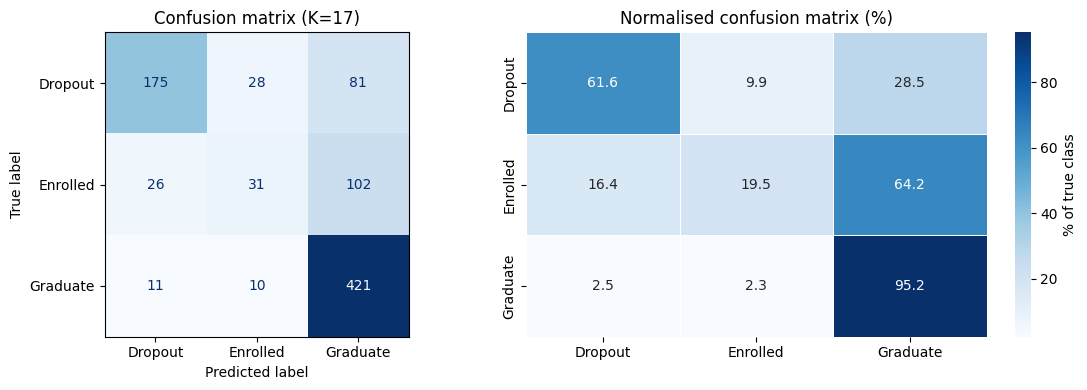

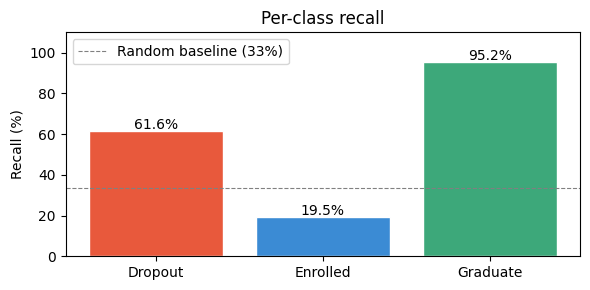

In [19]:
acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_wt  = f1_score(y_test, y_pred, average='weighted')

print('=' * 48)
print('           KNN TEST RESULTS')
print('=' * 48)
print(f'  K (optimal):        {best_k}')
print(f'  Test accuracy:      {acc:.4f}  ({acc*100:.1f}%)')
print(f'  F1 (macro):         {f1_mac:.4f}')
print(f'  F1 (weighted):      {f1_wt:.4f}')
print('=' * 48)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion matrix (K={best_k})')

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of true class'}, ax=axes[1])
axes[1].set_title('Normalised confusion matrix (%)')
plt.tight_layout(); plt.show()

# Per-class recall bar
recalls = [cm[i,i]/cm[i].sum()*100 for i in range(3)]
plt.figure(figsize=(6, 3))
bars = plt.bar(le.classes_, recalls, color=['#E8593C','#3B8BD4','#3DA87A'], edgecolor='white')
for b, v in zip(bars, recalls): plt.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontsize=10)
plt.axhline(100/3, linestyle='--', color='gray', linewidth=0.8, label='Random baseline (33%)')
plt.title('Per-class recall'); plt.ylabel('Recall (%)'); plt.ylim(0, 110); plt.legend(); plt.tight_layout(); plt.show()

In [21]:
from imblearn.over_sampling import SMOTE

# With SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Training set size before SMOTE:', len(y_train))
print('Training set size after SMOTE: ', len(y_train_sm))
print('Class distribution after SMOTE:', dict(zip(le.classes_, np.bincount(y_train_sm))))

knn_sm = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)
knn_sm.fit(X_train_sm, y_train_sm)
y_pred_smote = knn_sm.predict(X_test)

Training set size before SMOTE: 3539
Training set size after SMOTE:  5301
Class distribution after SMOTE: {'Dropout': np.int64(1767), 'Enrolled': np.int64(1767), 'Graduate': np.int64(1767)}


In [23]:
# Metrics comparison table

y_pred_no_smote = y_pred   # Without SMOTE

def metrics(y_true, y_pred):
    return {
        'Accuracy':    accuracy_score(y_true, y_pred),
        'F1 macro':    f1_score(y_true, y_pred, average='macro'),
        'F1 weighted': f1_score(y_true, y_pred, average='weighted'),
    }

m_no = metrics(y_test, y_pred_no_smote)
m_sm = metrics(y_test, y_pred_smote)

print('\n' + '='*52)
print('       SMOTE vs NO-SMOTE — METRIC COMPARISON')
print('='*52)
print(f"{'Metric':<18} {'No SMOTE':>12} {'+ SMOTE':>12} {'Change':>8}")
print('-'*52)
for key in m_no:
    diff = m_sm[key] - m_no[key]
    print(f"{key:<18} {m_no[key]:>12.4f} {m_sm[key]:>12.4f} {diff:>+8.4f}")
print('='*52)


       SMOTE vs NO-SMOTE — METRIC COMPARISON
Metric                 No SMOTE      + SMOTE   Change
----------------------------------------------------
Accuracy                 0.7085       0.5977  -0.1107
F1 macro                 0.5942       0.5778  -0.0163
F1 weighted              0.6773       0.6277  -0.0496


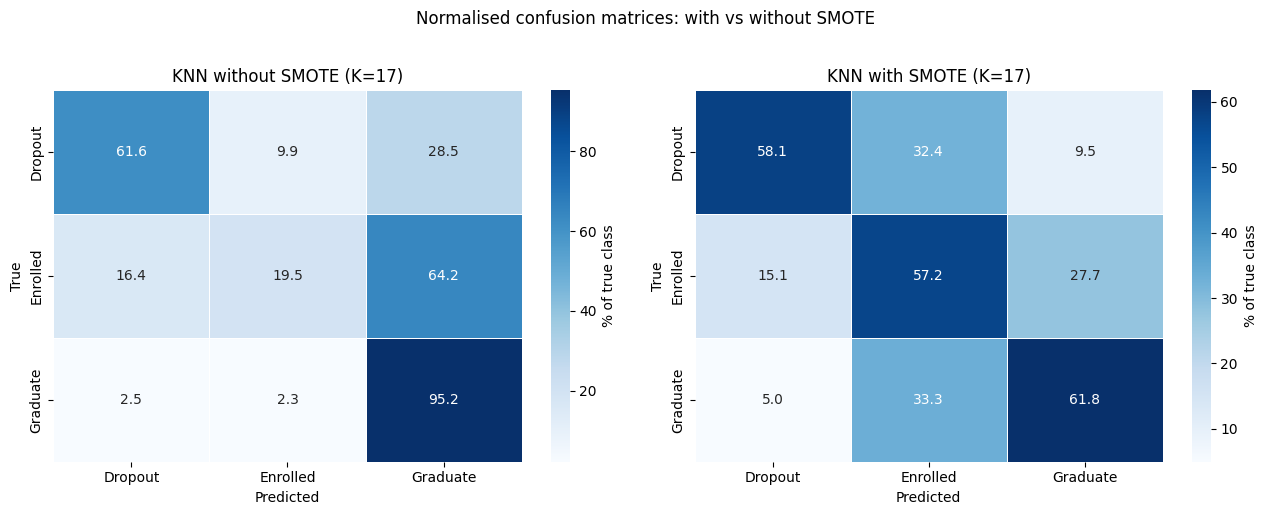

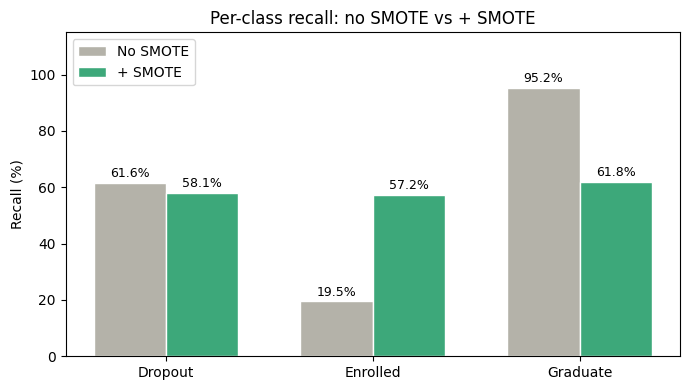

--- Without SMOTE ---
              precision    recall  f1-score   support

     Dropout       0.83      0.62      0.71       284
    Enrolled       0.45      0.19      0.27       159
    Graduate       0.70      0.95      0.80       442

    accuracy                           0.71       885
   macro avg       0.66      0.59      0.59       885
weighted avg       0.69      0.71      0.68       885

--- With SMOTE ---
              precision    recall  f1-score   support

     Dropout       0.78      0.58      0.67       284
    Enrolled       0.28      0.57      0.37       159
    Graduate       0.79      0.62      0.69       442

    accuracy                           0.60       885
   macro avg       0.62      0.59      0.58       885
weighted avg       0.70      0.60      0.63       885



In [24]:
# Side-by-side normalised confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in zip(
    axes,
    [y_pred_no_smote, y_pred_smote],
    [f'KNN without SMOTE (K={best_k})', f'KNN with SMOTE (K={best_k})']
):
    cm = confusion_matrix(y_test, pred).astype(float)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': '% of true class'}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Normalised confusion matrices: with vs without SMOTE', y=1.02)
plt.tight_layout(); plt.show()

# Per-class recall comparison bar chart
cm_no = confusion_matrix(y_test, y_pred_no_smote)
cm_sm = confusion_matrix(y_test, y_pred_smote)
recalls_no = [cm_no[i,i]/cm_no[i].sum()*100 for i in range(3)]
recalls_sm = [cm_sm[i,i]/cm_sm[i].sum()*100 for i in range(3)]

x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w/2, recalls_no, w, label='No SMOTE', color='#B4B2A9', edgecolor='white')
b2 = ax.bar(x + w/2, recalls_sm, w, label='+ SMOTE',  color='#3DA87A', edgecolor='white')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(le.classes_)
ax.set_ylabel('Recall (%)'); ax.set_ylim(0, 115)
ax.set_title('Per-class recall: no SMOTE vs + SMOTE')
ax.legend(); plt.tight_layout(); plt.show()

# Full classification reports
print('--- Without SMOTE ---')
print(classification_report(y_test, y_pred_no_smote, target_names=le.classes_))
print('--- With SMOTE ---')
print(classification_report(y_test, y_pred_smote, target_names=le.classes_))

In [30]:
# Download Model

import pickle
import os
from google.colab import files

os.makedirs('saved_models', exist_ok=True)
knn_bundle = {
    'model':    knn,
    'scaler':   scaler,
    'imputer':  imputer,
    'selector': sel,
    'encoder':  le,
}
with open('saved_models/knn_model.pkl', 'wb') as f:
    pickle.dump(knn_bundle, f)
print("KNN model saved -> saved_models/knn_model.pkl")

files.download('saved_models/knn_model.pkl')

KNN model saved -> saved_models/knn_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>